# Gamma Scalping and Volatility Analysis (Theoretical Fractional-Futures Hedging)

## 1. Project Objective

This notebook implements and evaluates a delta-hedged SPX straddle strategy using E-mini S&P 500 (ES) futures as the hedge instrument.

The analysis focuses on how gamma gains, theta decay, implied versus realised (subsequently) volatility, hedge frequency and transaction costs interact to determine strategy P&L (profit and loss).

In [135]:
# ES Gamma Scalping (Daily) — March 10–20, 2020

import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from statistics import NormalDist

In [136]:
plt.rcParams["figure.figsize"] = (10, 4) # set as default plot size

## 2. Model Configuration

This strategy models a long SPX straddle dynamically delta-hedged using E-mini S&P 500 futures. The configuration below defines the contract specifications, hedge rules, option assumptions, transaction costs and backtest period. Contract-specific March and June ES futures are represented separately so that the hedge roll can be handled explicitly without altering the strategy mechanics.

In [137]:
# Contract specifications
SPX_OPTION_MULTIPLIER = 100.0
ES_POINT_VALUE        = 50.0

# Strategy specification
N_STRADDLES           = 1
DELTA_REHEDGE_BAND    = 0.10
COMMISSION_PER_ES     = 1.25

# Option assumptions
RISK_FREE_RATE        = 0.0
OPTION_EXPIRY         = pd.Timestamp("2020-03-20")
STRIKE_INTERVAL       = 5.0

# Market data
SPX_TICKER            = "^GSPC"
VOL_TICKER            = "^VIX9D"

# Contract-specific ES hedge data
ES_MARCH_CONTRACT     = "ESH20"
ES_JUNE_CONTRACT      = "ESM20"
ES_ROLL_DATE          = pd.Timestamp("2020-03-12")
ES_DATA_FILE          = "Data/es_futures_mar2020.csv"

# Backtest period
INTERVAL              = "1d"
START                 = "2020-03-10"
END                   = "2020-03-21"  # yfinance end date is exclusive

## 3. Data collection and preparation

SPX and short-dated implied-volatility observations are aligned with contract-specific March and June 2020 E-mini S&P 500 futures data over the backtest period. SPX provides underlying level for the options position and ES provides the hedge instrument.

The straddle strike is fixed at incpetion. Time to expiry declines throughout the option life. Offical CME settlement prices are used as the daily ES hedge mark as they are available consistently for both contracts across the backtest window. 

March and June contracts remain separate around the roll. This ensures price difference between the two contracts is not recorded as hedge P&L.

In [138]:
def download_close_series(ticker, column_name):
    
    raw = yf.download(
        ticker,
        start=START,
        end=END,
        interval=INTERVAL,
        auto_adjust=False,
        progress=False,
    )

    if raw is None or raw.empty:
        raise RuntimeError(f"No data returned for {ticker}.")

    if isinstance(raw.columns, pd.MultiIndex):
        if "Close" not in raw.columns.get_level_values(0):
            raise RuntimeError(f"No Close column returned for {ticker}.")

        close = raw["Close"]

        if isinstance(close, pd.DataFrame):
            close = close.iloc[:, 0]

    else:
        if "Close" not in raw.columns:
            raise RuntimeError(f"No Close column returned for {ticker}.")

        close = raw["Close"]

    close = pd.to_numeric(
        close,
        errors="coerce"
    ).dropna()

    close.name = column_name
    close.index = pd.to_datetime(close.index)

    if close.index.tz is not None:
        close.index = close.index.tz_localize(None)

    close.index = close.index.normalize()

    return close.sort_index()

In [139]:
def load_es_contract_data(filepath):

    es_data = pd.read_csv(
        filepath,
        parse_dates=["Date"],
    )

    required_columns = [
        "Date",
        "ESH20_Settlement",
        "ESM20_Settlement",
    ]

    missing_columns = [
        column
        for column in required_columns
        if column not in es_data.columns
    ]

    if missing_columns:
        raise RuntimeError(
            "Missing required ES data columns: "
            + ", ".join(missing_columns)
        )

    es_data = (
        es_data
        .set_index("Date")
        .sort_index()
    )

    es_data.index = (
        pd.to_datetime(es_data.index)
        .tz_localize(None)
        .normalize()
    )

    if es_data.index.has_duplicates:
        raise RuntimeError(
            "Duplicate dates found in the ES futures dataset."
        )

    # Convert all available ES data fields to numeric values while
    # retaining optional volume and open-interest columns if present.
    es_data = es_data.apply(
        pd.to_numeric,
        errors="coerce",
    )

    settlement_columns = [
        "ESH20_Settlement",
        "ESM20_Settlement",
    ]

    if es_data[settlement_columns].isna().any().any():
        raise RuntimeError(
            "Missing ES settlement observations found."
        )

    return es_data

In [140]:
# Download the market series used by the option model.
spx = download_close_series(
    SPX_TICKER,
    "SPX",
)

vol_proxy = download_close_series(
    VOL_TICKER,
    "VIX9D",
)

# Load the locally prepared contract-specific ES settlement data.
es_contracts = load_es_contract_data(
    ES_DATA_FILE
)

# Align the option and hedge inputs to common trading dates.
market = pd.concat(
    [
        spx,
        vol_proxy,
        es_contracts,
    ],
    axis=1,
    join="inner",
).dropna(
    subset=["SPX", "VIX9D"]
).sort_index()

market = market.loc[
    (market.index >= pd.Timestamp(START))
    & (market.index <= OPTION_EXPIRY)
].copy()

if market.empty:
    raise RuntimeError(
        "No common market observations remain after aligning the input datasets."
    )

# The theoretical backtest requires observations at both inception and expiry.
backtest_start = pd.Timestamp(START).normalize()
option_expiry = OPTION_EXPIRY.normalize()

if backtest_start not in market.index:
    raise RuntimeError(
        "Backtest-start observation is missing from the aligned market dataset."
    )

if option_expiry not in market.index:
    raise RuntimeError(
        "Option-expiry observation is missing from the aligned market dataset."
    )

# Validate the underlying and implied-volatility proxy inputs.
if (market["SPX"] <= 0).any():
    raise RuntimeError(
        "SPX contains non-positive observations."
    )

market["iv_proxy"] = (
    market["VIX9D"] / 100.0
)

if (market["iv_proxy"] <= 0).any():
    raise RuntimeError(
        "VIX9D implied-volatility proxy contains non-positive observations."
    )

# Fix the straddle strike once at inception.
initial_spx = market["SPX"].iloc[0]

STRIKE = (
    round(initial_spx / STRIKE_INTERVAL)
    * STRIKE_INTERVAL
)

market["K"] = STRIKE

# Let time to expiry decline using calendar time.
market["days_to_expiry"] = (
    option_expiry
    - market.index
).days

market["T"] = (
    market["days_to_expiry"]
    / 365.0
)

if (market["T"] < 0).any():
    raise RuntimeError(
        "Market data extend beyond option expiry."
    )

# Treat the roll date as the close at which the hedge moves from March to June.
market["ES_contract"] = np.where(
    market.index < ES_ROLL_DATE,
    ES_MARCH_CONTRACT,
    ES_JUNE_CONTRACT,
)

market["is_roll_date"] = (
    market.index == ES_ROLL_DATE
)

market["ES_settlement"] = np.where(
    market.index < ES_ROLL_DATE,
    market["ESH20_Settlement"],
    market["ESM20_Settlement"],
)

# Calculate each hedge return within the contract actually held over that interval.
march_settlement_change = (
    market["ESH20_Settlement"].diff()
)

june_settlement_change = (
    market["ESM20_Settlement"].diff()
)

previous_contract = (
    market["ES_contract"].shift(1)
)

market["ES_settlement_change"] = np.select(
    [
        previous_contract.eq(ES_MARCH_CONTRACT),
        previous_contract.eq(ES_JUNE_CONTRACT),
    ],
    [
        march_settlement_change,
        june_settlement_change,
    ],
    default=np.nan,
)

# Retain SPX returns for later realised-volatility analysis.
market["SPX_log_return"] = np.log(
    market["SPX"]
    / market["SPX"].shift(1)
)

print(f"Backtest observations: {len(market)}")
print(f"Initial SPX level:      {initial_spx:.2f}")
print(f"Straddle strike:        {STRIKE:.0f}")
print(f"Option expiry:          {OPTION_EXPIRY.date()}")
print(f"ES roll date:           {ES_ROLL_DATE.date()}")

display(
    market[
        [
            "SPX",
            "VIX9D",
            "iv_proxy",
            "K",
            "days_to_expiry",
            "T",
            "ES_contract",
            "ES_settlement",
            "ES_settlement_change",
        ]
    ]
)

Backtest observations: 9
Initial SPX level:      2882.23
Straddle strike:        2880
Option expiry:          2020-03-20
ES roll date:           2020-03-12


,SPX,VIX9D,iv_proxy,K,days_to_expiry,T,ES_contract,ES_settlement,ES_settlement_change
Date,,,,,,,,,
2020-03-10,2882.229980,57.389999,0.5739,2880.0,10,0.027397,ESH20,2865.75,NaN
2020-03-11,2741.379883,68.209999,0.6821,2880.0,9,0.024658,ESH20,2740.25,-125.50
2020-03-12,2480.639893,103.559998,1.0356,2880.0,8,0.021918,ESM20,2456.00,-271.25
2020-03-13,2711.020020,69.870003,0.6987,2880.0,7,0.019178,ESM20,2684.00,228.00
2020-03-16,2386.129883,106.660004,1.0666,2880.0,4,0.010959,ESM20,2405.25,-278.75
2020-03-17,2529.189941,92.930000,0.9293,2880.0,3,0.008219,ESM20,2485.50,80.25
2020-03-18,2398.100098,97.220001,0.9722,2880.0,2,0.005479,ESM20,2401.50,-84.00
2020-03-19,2409.389893,91.019997,0.9102,2880.0,1,0.002740,ESM20,2389.00,-12.50
2020-03-20,2304.919922,83.470001,0.8347,2880.0,0,0.000000,ESM20,2288.50,-100.50


## 4. Option pricing and Greeks

Black-Scholes is used to value the call and put forming the long SPX straddle and to calculate the position's delta, gamma and theta at each observation.

Option values and Greeks are calculated in SPX index-point terms in this section. The SPX contract multiplier is applied later in the backtest when translating these exposures into dollar P&L and determining the required ES futures hedge.

At expiry, the call and put are valued at intrinsic value and the remaining gamma and theta exposures are set to zero. This avoids numerical instability as time to expiry approaches zero and allows the strategy to be evaluated using actual option repricing, while the Greeks are retained for hedge construction and P&L attribution.

In [141]:
N = NormalDist(0, 1)


def normal_pdf(x):
    """Standard normal probability density function."""
    return np.exp(-0.5 * x**2) / np.sqrt(2.0 * np.pi)


def d1(S, K, r, sigma, T):
    """Black-Scholes d1 for a positive-volatility, pre-expiry option."""
    return (
        np.log(S / K)
        + (r + 0.5 * sigma**2) * T
    ) / (
        sigma * np.sqrt(T)
    )


def d2(S, K, r, sigma, T):
    """Black-Scholes d2."""
    return d1(S, K, r, sigma, T) - sigma * np.sqrt(T)


def call_price(S, K, r, sigma, T):
    """Black-Scholes European call value in index points."""
    if T <= 0:
        return max(S - K, 0.0)

    if sigma <= 0:
        return max(S - K * np.exp(-r * T), 0.0)

    d1_ = d1(S, K, r, sigma, T)
    d2_ = d2(S, K, r, sigma, T)

    return (
        S * N.cdf(d1_)
        - K * np.exp(-r * T) * N.cdf(d2_)
    )


def put_price(S, K, r, sigma, T):
    """Black-Scholes European put value in index points."""
    if T <= 0:
        return max(K - S, 0.0)

    if sigma <= 0:
        return max(K * np.exp(-r * T) - S, 0.0)

    d1_ = d1(S, K, r, sigma, T)
    d2_ = d2(S, K, r, sigma, T)

    return (
        K * np.exp(-r * T) * N.cdf(-d2_)
        - S * N.cdf(-d1_)
    )


def delta_call(S, K, r, sigma, T):
    """Call delta per index point."""
    if T <= 0:
        if S > K:
            return 1.0
        if S < K:
            return 0.0
        return 0.5

    if sigma <= 0:
        return 1.0 if S > K * np.exp(-r * T) else 0.0

    return N.cdf(
        d1(S, K, r, sigma, T)
    )


def delta_put(S, K, r, sigma, T):
    """Put delta per index point."""
    if T <= 0:
        if S > K:
            return 0.0
        if S < K:
            return -1.0
        return -0.5

    if sigma <= 0:
        return 0.0 if S > K * np.exp(-r * T) else -1.0

    return N.cdf(
        d1(S, K, r, sigma, T)
    ) - 1.0


def gamma_bs(S, K, r, sigma, T):
    """Black-Scholes gamma per index point."""
    if T <= 0 or sigma <= 0:
        return 0.0

    d1_ = d1(S, K, r, sigma, T)

    return normal_pdf(d1_) / (
        S * sigma * np.sqrt(T)
    )


def theta_call(S, K, r, sigma, T):
    """Annualised Black-Scholes call theta in index points."""
    if T <= 0 or sigma <= 0:
        return 0.0

    d1_ = d1(S, K, r, sigma, T)
    d2_ = d2(S, K, r, sigma, T)

    return (
        -(S * normal_pdf(d1_) * sigma)
        / (2.0 * np.sqrt(T))
        - r * K * np.exp(-r * T) * N.cdf(d2_)
    )


def theta_put(S, K, r, sigma, T):
    """Annualised Black-Scholes put theta in index points."""
    if T <= 0 or sigma <= 0:
        return 0.0

    d1_ = d1(S, K, r, sigma, T)
    d2_ = d2(S, K, r, sigma, T)

    return (
        -(S * normal_pdf(d1_) * sigma)
        / (2.0 * np.sqrt(T))
        + r * K * np.exp(-r * T) * N.cdf(-d2_)
    )


def straddle_metrics(S, K, sigma, T, n=1.0):
    """Return theoretical value and Greeks for a long SPX straddle."""

    call = call_price(
        S, K, RISK_FREE_RATE, sigma, T
    )

    put = put_price(
        S, K, RISK_FREE_RATE, sigma, T
    )

    call_delta = delta_call(
        S, K, RISK_FREE_RATE, sigma, T
    )

    put_delta = delta_put(
        S, K, RISK_FREE_RATE, sigma, T
    )

    gamma = gamma_bs(
        S, K, RISK_FREE_RATE, sigma, T
    )

    theta = (
        theta_call(
            S, K, RISK_FREE_RATE, sigma, T
        )
        + theta_put(
            S, K, RISK_FREE_RATE, sigma, T
        )
    )

    return {
        "call_price": n * call,
        "put_price": n * put,
        "straddle_price": n * (call + put),
        "delta": n * (call_delta + put_delta),
        "gamma": n * 2.0 * gamma,
        "theta": n * theta,
    }


def target_es_hedge(option_delta):
    """
    Convert SPX option delta into the fractional ES position
    required to offset the option's dollar delta.
    """
    return (
        -option_delta
        * SPX_OPTION_MULTIPLIER
        / ES_POINT_VALUE
    )


test_metrics = straddle_metrics(
    S=market["SPX"].iloc[0],
    K=STRIKE,
    sigma=market["iv_proxy"].iloc[0],
    T=market["T"].iloc[0],
    n=N_STRADDLES,
)

test_metrics

{'call_price': np.float64(110.26193617742229),
 'put_price': np.float64(108.03195570867251),
 'straddle_price': np.float64(218.2938918860948),
 'delta': 0.0443748235203294,
 'gamma': np.float64(0.0029097072217441006),
 'theta': np.float64(-3980.6042209610096)}

## 5. Delta-hedged Gamma-scalping backtest

The straddle is marked each day using the Black-Scholes value from Section 4, while the ES hedge earns settlement-to-settlement P&L in the contract actually held over each interval. The option delta is translated into fractional ES contract-equivalent exposure using the SPX option multiplier and ES point value.

The hedge is rebalanced when residual SPX-equivalent delta exceeds the configured band and is explicitly rolled from March to June on the roll date. Futures commissions are charged on opening, rehedging and rolling and closing transactions. 

On option expiry, the final option value is sttled at intrinsic value and the remaining ES hedge is closed so that the strategy terminates with zero futures exposure. 

In [142]:
# Run the daily delta-hedged straddle backtest.
records = []

first_date = market.index[0]
first_row = market.iloc[0]

first_metrics = straddle_metrics(
    S=first_row["SPX"],
    K=first_row["K"],
    sigma=first_row["iv_proxy"],
    T=first_row["T"],
    n=N_STRADDLES,
)

# Convert the option's initial delta into the exact fractional ES hedge.
q_fut = target_es_hedge(
    first_metrics["delta"]
)

entry_contracts_traded = abs(q_fut)

entry_commission = (
    COMMISSION_PER_ES
    * entry_contracts_traded
)

records.append(
    {
        "Date": first_date,
        "SPX": first_row["SPX"],
        "VIX9D": first_row["VIX9D"],
        "straddle_price": first_metrics["straddle_price"],
        "delta": first_metrics["delta"],
        "gamma": first_metrics["gamma"],
        "theta": first_metrics["theta"],
        "ES_contract": first_row["ES_contract"],
        "ES_settlement_change": np.nan,
        "net_delta_before": first_metrics["delta"],
        "q_fut_start": 0.0,
        "q_fut_end": q_fut,
        "contracts_traded": entry_contracts_traded,
        "option_pnl": 0.0,
        "hedge_pnl": 0.0,
        "commission": entry_commission,
        "total_pnl": -entry_commission,
        "delta_attribution": 0.0,
        "gamma_attribution": 0.0,
        "theta_attribution": 0.0,
        "option_residual": 0.0,
        "event": "OPEN",
    }
)

prev_date = first_date
prev_row = first_row
prev_metrics = first_metrics
prev_contract = first_row["ES_contract"]

for ts, row in market.iloc[1:].iterrows():
    metrics = straddle_metrics(
        S=row["SPX"],
        K=row["K"],
        sigma=row["iv_proxy"],
        T=row["T"],
        n=N_STRADDLES,
    )

    # Reprice the theoretical SPX straddle.
    option_pnl = (
        metrics["straddle_price"]
        - prev_metrics["straddle_price"]
    ) * SPX_OPTION_MULTIPLIER

    if pd.isna(row["ES_settlement_change"]):
        raise RuntimeError(
            f"Missing ES settlement change for {ts.date()}."
        )

    # The futures quantity held at the start of the interval earns
    # the settlement-to-settlement hedge P&L for that interval.
    q_fut_start = q_fut

    hedge_pnl = (
        q_fut_start
        * ES_POINT_VALUE
        * row["ES_settlement_change"]
    )

    # Attribute the option-price change using previous-period Greeks.
    dS = row["SPX"] - prev_row["SPX"]
    dt_year = (ts - prev_date).days / 365.0

    delta_attribution = (
        prev_metrics["delta"]
        * SPX_OPTION_MULTIPLIER
        * dS
    )

    gamma_attribution = (
        0.5
        * prev_metrics["gamma"]
        * SPX_OPTION_MULTIPLIER
        * dS**2
    )

    theta_attribution = (
        prev_metrics["theta"]
        * SPX_OPTION_MULTIPLIER
        * dt_year
    )

    option_residual = (
        option_pnl
        - delta_attribution
        - gamma_attribution
        - theta_attribution
    )

    # Measure residual SPX-equivalent delta before any end-of-day trade.
    net_delta_before = (
        metrics["delta"]
        + q_fut_start
        * ES_POINT_VALUE
        / SPX_OPTION_MULTIPLIER
    )

    q_target = q_fut_start
    contracts_traded = 0.0
    event = "HOLD"

    contract_changed = (
        row["ES_contract"] != prev_contract
    )

    is_expiry = (
        ts.normalize()
        == OPTION_EXPIRY.normalize()
    )

    if is_expiry:
        # The option has settled at intrinsic value.
        # No option exposure remains after settlement, so close the ES hedge.
        q_target = 0.0

        contracts_traded = abs(
            q_fut_start
        )

        event = "EXPIRY_CLOSE"

    elif contract_changed:
        # Close the old contract and establish the exact fractional
        # delta hedge in the new contract.
        q_target = target_es_hedge(
            metrics["delta"]
        )

        contracts_traded = (
            abs(q_fut_start)
            + abs(q_target)
        )

        event = "ROLL"

    elif abs(net_delta_before) > DELTA_REHEDGE_BAND:
        # Rehedge only when residual SPX-equivalent delta exceeds the band.
        q_target = target_es_hedge(
            metrics["delta"]
        )

        contracts_traded = abs(
            q_target - q_fut_start
        )

        event = "REHEDGE"

    commission = (
        COMMISSION_PER_ES
        * contracts_traded
    )

    total_pnl = (
        option_pnl
        + hedge_pnl
        - commission
    )

    records.append(
        {
            "Date": ts,
            "SPX": row["SPX"],
            "VIX9D": row["VIX9D"],
            "straddle_price": metrics["straddle_price"],
            "delta": metrics["delta"],
            "gamma": metrics["gamma"],
            "theta": metrics["theta"],
            "ES_contract": row["ES_contract"],
            "ES_settlement_change": row["ES_settlement_change"],
            "net_delta_before": net_delta_before,
            "q_fut_start": q_fut_start,
            "q_fut_end": q_target,
            "contracts_traded": contracts_traded,
            "option_pnl": option_pnl,
            "hedge_pnl": hedge_pnl,
            "commission": commission,
            "total_pnl": total_pnl,
            "delta_attribution": delta_attribution,
            "gamma_attribution": gamma_attribution,
            "theta_attribution": theta_attribution,
            "option_residual": option_residual,
            "event": event,
        }
    )

    q_fut = q_target
    prev_date = ts
    prev_row = row
    prev_metrics = metrics
    prev_contract = row["ES_contract"]

## 6. Results

Daily results separate theoretical SPX straddle repricing from ES futures hedge P&L and futures commissions. 

Greeks: delta, gamma, theta are reatained as an attribution of the option-price change. The residual captures implied-volatility changes and higher-order approximation error.

In [143]:
# Summarise daily strategy P&L and volatility conditions.
res = (
    pd.DataFrame(records)
    .set_index("Date")
    .sort_index()
)

res["cum_pnl"] = (
    res["total_pnl"].cumsum()
)

res["option_attribution_sum"] = (
    res["delta_attribution"]
    + res["gamma_attribution"]
    + res["theta_attribution"]
    + res["option_residual"]
)

# Verify that the option-attribution components reconcile to option P&L.
if not np.allclose(
    res["option_attribution_sum"],
    res["option_pnl"],
    atol=1e-8,
    rtol=1e-10,
):
    raise RuntimeError(
        "Option P&L attribution does not reconcile."
    )

# Verify that the backtest terminates at option expiry.
if res.index[-1].normalize() != OPTION_EXPIRY.normalize():
    raise RuntimeError(
        "Backtest does not terminate on option expiry."
    )

# Verify that the terminal ES hedge has been fully closed.
if not np.isclose(
    res["q_fut_end"].iloc[-1],
    0.0,
    atol=1e-12,
):
    raise RuntimeError(
        "Backtest ended with an open ES hedge."
    )

# Verify that the terminal trade was explicitly recorded.
if res["event"].iloc[-1] != "EXPIRY_CLOSE":
    raise RuntimeError(
        "Final backtest event is not EXPIRY_CLOSE."
    )

realised_vol = (
    market["SPX_log_return"]
    .dropna()
    .std(ddof=1)
    * np.sqrt(252.0)
)

summary = pd.Series(
    {
        "Total P&L (USD)": res["total_pnl"].sum(),
        "Option P&L (USD)": res["option_pnl"].sum(),
        "ES hedge P&L (USD)": res["hedge_pnl"].sum(),
        "Futures commissions (USD)": res["commission"].sum(),
        "Total ES turnover": res["contracts_traded"].sum(),
        "Rehedges": int(
            (res["event"] == "REHEDGE").sum()
        ),
        "Contract rolls": int(
            (res["event"] == "ROLL").sum()
        ),
        "Expiry hedge closes": int(
            (res["event"] == "EXPIRY_CLOSE").sum()
        ),
        "Ending ES position": res["q_fut_end"].iloc[-1],
        "Initial VIX9D proxy": market["iv_proxy"].iloc[0],
        "Realised SPX volatility": realised_vol,
    },
    name="Value",
)

display(
    res[
        [
            "SPX",
            "VIX9D",
            "ES_contract",
            "delta",
            "net_delta_before",
            "q_fut_start",
            "q_fut_end",
            "contracts_traded",
            "option_pnl",
            "hedge_pnl",
            "commission",
            "total_pnl",
            "cum_pnl",
            "event",
        ]
    ]
)

display(summary.to_frame())

,SPX,VIX9D,ES_contract,delta,net_delta_before,q_fut_start,q_fut_end,contracts_traded,option_pnl,hedge_pnl,commission,total_pnl,cum_pnl,event
Date,,,,,,,,,,,,,,
2020-03-10,2882.229980,57.389999,ESH20,0.044375,0.044375,0.000000,-0.088750,0.088750,0.000000,0.000000,0.110937,-0.110937,-0.110937,OPEN
2020-03-11,2741.379883,68.209999,ESH20,-0.315990,-0.360365,-0.088750,0.631981,0.720730,4678.416327,556.904035,0.900913,5234.419449,5234.308512,REHEDGE
2020-03-12,2480.639893,103.559998,ESM20,-0.630265,-0.314274,0.631981,1.260529,1.892510,20593.318968,-8571.237670,2.365637,12019.715661,17254.024174,ROLL
2020-03-13,2711.020020,69.870003,ESM20,-0.435739,0.194526,1.260529,0.871478,0.389051,-21451.717368,14370.031119,0.486314,-7082.172562,10171.851611,REHEDGE
2020-03-16,2386.129883,106.660004,ESM20,-0.896677,-0.460939,0.871478,1.793355,0.921877,24847.231118,-12146.224098,1.152346,12699.854674,22871.706285,REHEDGE
2020-03-17,2529.189941,92.930000,ESM20,-0.866284,0.030393,1.793355,1.793355,0.000000,-14205.418477,7195.836909,0.000000,-7009.581568,15862.124717,HOLD
2020-03-18,2398.100098,97.220001,ESM20,-0.987875,-0.091197,1.793355,1.793355,0.000000,11964.730181,-7532.090970,0.000000,4432.639211,20294.763928,HOLD
2020-03-19,2409.389893,91.019997,ESM20,-0.999802,-0.103124,1.793355,1.999603,0.206248,-1194.400127,-1120.846871,0.257810,-2315.504808,17979.259121,REHEDGE
2020-03-20,2304.919922,83.470001,ESM20,-1.000000,-0.000198,1.999603,0.000000,1.999603,10446.458001,-10048.006687,2.499504,395.951810,18375.210931,EXPIRY_CLOSE


,Value
Total P&L (USD),18375.210931
Option P&L (USD),35678.618624
ES hedge P&L (USD),-17295.634231
Futures commissions (USD),7.773462
Total ES turnover,6.218769
Rehedges,4.000000
Contract rolls,1.000000
Expiry hedge closes,1.000000
Ending ES position,0.000000
Initial VIX9D proxy,0.573900


## 7. Visualisation

The plots show daily and cumulative strategy P&L, together with main option and hedge components. Commission costs are plotted as negative P&L - so components match visually with total strategy result.

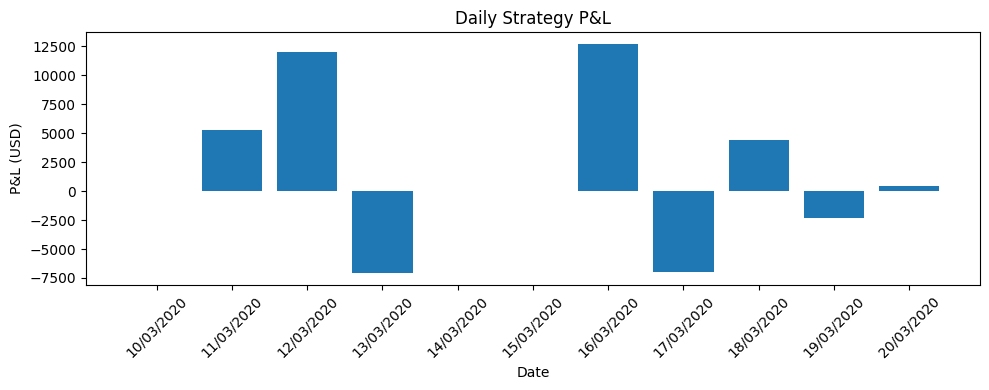

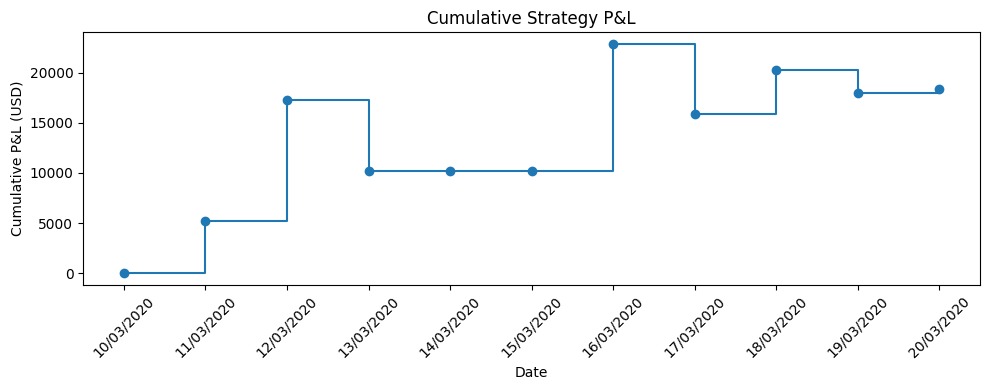

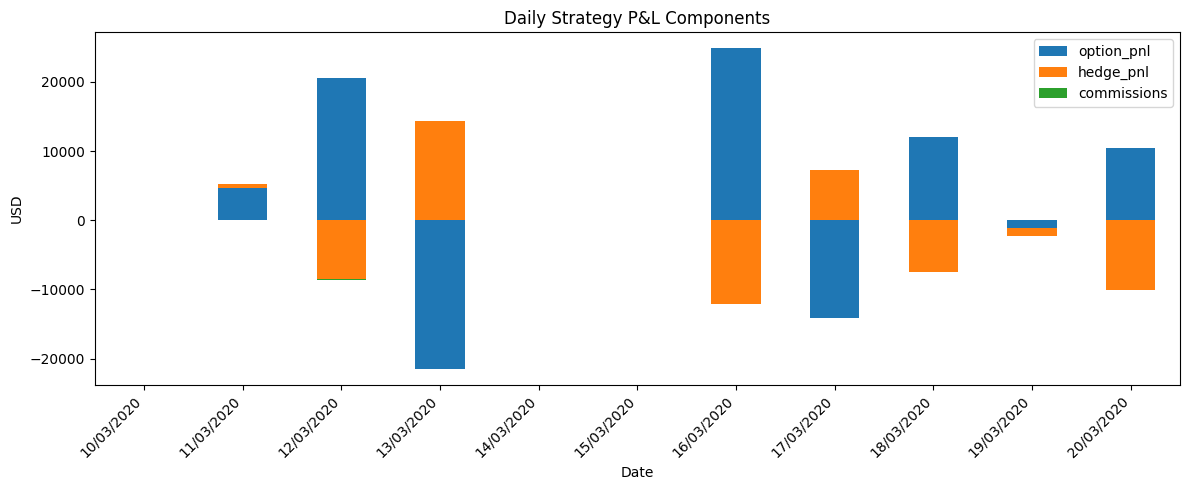

In [144]:
import matplotlib.dates as mdates

# Create a complete calendar-date range for plotting.
calendar_dates = pd.date_range(
    res.index.min(),
    res.index.max(),
    freq="D",
)

# Plot daily strategy P&L across all calendar dates.
# Non-trading days are shown as zero-P&L observations for presentation only.
daily_pnl_plot = (
    res["total_pnl"]
    .reindex(calendar_dates, fill_value=0.0)
)

plt.figure()

plt.bar(
    daily_pnl_plot.index,
    daily_pnl_plot,
)

plt.title("Daily Strategy P&L")
plt.xlabel("Date")
plt.ylabel("P&L (USD)")

plt.gca().xaxis.set_major_locator(
    mdates.DayLocator(interval=1)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%d/%m/%Y")
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Plot cumulative strategy P&L across all calendar dates.
# Non-trading weekend dates carry forward the most recent closing P&L.
calendar_dates = pd.date_range(
    res.index.min(),
    res.index.max(),
    freq="D",
)

cumulative_pnl_plot = (
    res["cum_pnl"]
    .reindex(calendar_dates)
    .ffill()
)

plt.figure()

plt.step(
    cumulative_pnl_plot.index,
    cumulative_pnl_plot,
    where="post",
    marker="o",
)

plt.title("Cumulative Strategy P&L")
plt.xlabel("Date")
plt.ylabel("Cumulative P&L (USD)")

plt.gca().xaxis.set_major_locator(
    mdates.DayLocator(interval=1)
)

plt.gca().xaxis.set_major_formatter(
    mdates.DateFormatter("%d/%m/%Y")
)

plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Add non-trading calendar dates as zero-P&L observations for plotting only.
pnl_components_plot = (
    pnl_components
    .reindex(calendar_dates, fill_value=0.0)
)

ax = pnl_components_plot.plot(
    kind="bar",
    figsize=(12, 5),
    stacked=True,
)

ax.set_title("Daily Strategy P&L Components")
ax.set_xlabel("Date")
ax.set_ylabel("USD")

ax.set_xticklabels(
    [
        date.strftime("%d/%m/%Y")
        for date in pnl_components_plot.index
    ],
    rotation=45,
    ha="right",
)

plt.tight_layout()
plt.show()

## 8 Limitations

This notebook is designed as a theoretical benchmark, not a fully executable trading simulation. The main limitations are as follows:

- **Implied Volatility Proxy:** VIX9D is used as the volatility input to the Black-Scholes model rather than strike-specific implied volatility for the selected SPX call and put. This means the theoretical straddle value approximates the historical market price of the actual option position rather than reproducing it.

- **Fractional Futures:** The ES hedg ecan take fractional contract quantities. THis allows the model to isolate the theoretical effect of near-exact delta-hedging. However, fractional ES contracts can not be traded in practice.

- **Discrete Hedging:** Hedging only occurs at the available daily observations and when residual SPX-equivalent delta exceeds the rehedge band. This means the strategy represents discrete delta-hedging rather than continuous gamma-scalping.

- **SPX and ES price conventions:** The option is marked using SPX closing levels while the hedge is valued using official ES settlement prices. Differences in timing and market conventions may introduce additional basis effects.

- **SPX–ES basis risk:** ES futures are used as a proxy hedge for SPX exposure. Changes in the futures basis can therefore cause hedge P&L to differ from the P&L implied by movements in the spot index alone.

- **Transaction-cost simplification:** Futures commissions are modelled as a constant linear cost per fractional ES contract traded. Bid-ask spreads, slippage, market impact and other execution costs are not included.

- **Option-market frictions:** The model does not incorporate option bid-ask spreads, execution costs, liquidity constraints or deviations of traded option prices from Black-Scholes theoretical values.

- **Greek attribution:** Delta, gamma and theta are used to attribute the option-price change. The residual therefore contains the effects of changes in implied volatility, higher-order Greeks and approximation error, and should not be interpreted as pure vega P&L.

- **Short stress-period sample:** The analysis covers a small number of observations during the unusually volatile March 2020 market environment. Results therefore illustrate the mechanics of gamma scalping under stressed conditions rather than providing evidence of long-run strategy performance.

These limitations are intentional for the theoretical version. The framework provides a controlled benchmark that can subsequently be compared with a more realistic implementation using integer ES contracts, alternative hedge frequencies, additional trading frictions and more granular option-market data.

